In [1]:
# =========================
# Install libraries
# =========================
!pip install xgboost lightgbm -q

In [2]:
# =========================
# Imports
# =========================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.svm import SVC, OneClassSVM
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [4]:
# =========================
# 1. Load IoT-23 Zeek file
# =========================

file_path = "/content/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"

# The previous code block for extracting columns (with open(...) and #fields) is removed
# because the file format seems to be a standard CSV with a header, not requiring
# special parsing for column names from a '#fields' line.

df = pd.read_csv(
    file_path,
    sep=",", # Changed separator to comma for a .csv file
    # Removed 'comment="#"' and 'names=columns' as pandas will infer headers by default
    low_memory=False
)

df.columns = df.columns.str.strip()

print("Original dataset shape:", df.shape)
print(df.head())

Original dataset shape: (225745, 79)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                     

In [5]:
# =========================
# 2. Data cleaning
# =========================

df = df.replace(["-", "?", "nan", "NaN", "inf", "-inf", "Infinity"], np.nan)

# The original 'features' list was for a different dataset and none of them exist in the current df.
# We will dynamically create the features list to include all columns except the 'Label' column.
all_columns = df.columns.tolist()
if "Label" in all_columns:
    features = [col for col in all_columns if col != "Label"]
    label_column_name = "Label"
else:
    # Fallback if 'Label' is not found, though it should be based on previous output
    print("Warning: 'Label' column not found. Please check column names.")
    features = all_columns
    label_column_name = None # Indicate that label column was not identified

# Ensure 'label_column_name' is not None before proceeding with df_model creation
if label_column_name is None:
    raise KeyError("Label column could not be identified. Cannot proceed.")

# Create df_model with relevant features and the correct label column
df_model = df[features + [label_column_name]].copy()

# Categorical feature 'conn_state' might not be present in the current dataset.
# Check if 'conn_state' is in the features list before attempting to convert.
if "conn_state" in df_model.columns:
    df_model["conn_state"] = df_model["conn_state"].astype("category").cat.codes

# Label: Benign = 0, Attack = 1
df_model[label_column_name] = df_model[label_column_name].apply(
    lambda x: 0 if str(x).strip().lower() == "benign" else 1
)

# Convert features to numeric
for col in features:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# Remove infinity and fill missing values
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)
df_model[features] = df_model[features].fillna(df_model[features].median())
df_model[features] = df_model[features].fillna(0)

print("Cleaned dataset shape:", df_model.shape)
print("Label distribution:")
print(df_model[label_column_name].value_counts())

print("NaN count:", df_model[features].isna().sum().sum())

Cleaned dataset shape: (225745, 79)
Label distribution:
Label
1    128027
0     97718
Name: count, dtype: int64
NaN count: 0


In [6]:
# =========================
# 3. Split X and y
# =========================

X = df_model[features]
y = df_model[label_column_name]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
# =========================
# 4. Scale features
# =========================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Benign-only training data for unsupervised models
X_train_normal = X_train_scaled[y_train == 0]

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("X_train_normal:", X_train_normal.shape)

print("NaN in train:", np.isnan(X_train_scaled).sum())
print("NaN in test:", np.isnan(X_test_scaled).sum())

X_train_scaled: (180596, 78)
X_test_scaled: (45149, 78)
X_train_normal: (78174, 78)
NaN in train: 0
NaN in test: 0


In [8]:
# =========================
# Supervised ML models
# =========================

supervised_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1
    )
}

In [9]:
# =========================
# Evaluate supervised models
# =========================

supervised_results = []
trained_supervised_models = {}

for name, model in supervised_models.items():
    print(f"\nTraining {name}...")

    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    y_pred = model.predict(X_test_scaled)
    pred_time = time.time() - start_pred

    latency = pred_time / len(X_test_scaled)

    try:
        y_score = model.predict_proba(X_test_scaled)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    except:
        auc = np.nan

    supervised_results.append({
        "Model": name,
        "Type": "Supervised",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": auc,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time,
        "Latency per Sample (s)": latency
    })

    trained_supervised_models[name] = model

supervised_results_df = pd.DataFrame(supervised_results)
supervised_results_df


Training Logistic Regression...

Training Decision Tree...

Training Random Forest...

Training SVM...

Training KNN...

Training XGBoost...

Training LightGBM...
[LightGBM] [Info] Number of positive: 102422, number of negative: 78174
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.142798 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14227
[LightGBM] [Info] Number of data points in the train set: 180596, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.567133 -> initscore=0.270164
[LightGBM] [Info] Start training from score 0.270164


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
0,Logistic Regression,Supervised,0.998715,0.998673,0.999063,0.998868,0.999887,12.018162,0.021862,4.842143e-07
1,Decision Tree,Supervised,0.999956,0.999961,0.999961,0.999961,0.999955,7.440128,0.033457,7.410361e-07
2,Random Forest,Supervised,0.999956,0.999961,0.999961,0.999961,1.000000,38.609870,0.338517,7.497773e-06
3,SVM,Supervised,0.998582,0.998478,0.999024,0.998751,0.999875,638.765838,23.341027,5.169777e-04
4,KNN,Supervised,0.999690,0.999688,0.999766,0.999727,0.999955,0.107148,91.698372,2.031017e-03
5,XGBoost,Supervised,0.999978,1.000000,0.999961,0.999980,1.000000,6.340545,0.220954,4.893883e-06
6,LightGBM,Supervised,0.999978,1.000000,0.999961,0.999980,1.000000,6.770995,0.115195,2.551442e-06


In [10]:
# =========================
# Unsupervised anomaly models
# =========================

unsupervised_models = {
    "Isolation Forest": IsolationForest(
        n_estimators=100,
        contamination=0.1,
        random_state=42
    ),

    "One-Class SVM": OneClassSVM(
        kernel="rbf",
        nu=0.1,
        gamma="scale"
    ),

    "Local Outlier Factor": LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.1,
        novelty=True
    )
}

In [11]:
# =========================
# Evaluate unsupervised models
# =========================

unsupervised_results = []
trained_unsupervised_models = {}

for name, model in unsupervised_models.items():
    print(f"\nTraining {name}...")

    start_train = time.time()
    model.fit(X_train_normal)
    train_time = time.time() - start_train

    start_pred = time.time()
    pred = model.predict(X_test_scaled)
    pred_time = time.time() - start_pred

    # sklearn anomaly output:
    # 1 = normal, -1 = anomaly
    y_pred = np.where(pred == -1, 1, 0)

    latency = pred_time / len(X_test_scaled)

    try:
        scores = -model.decision_function(X_test_scaled)
        auc = roc_auc_score(y_test, scores)
    except:
        auc = np.nan

    unsupervised_results.append({
        "Model": name,
        "Type": "Unsupervised",
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": auc,
        "Training Time (s)": train_time,
        "Prediction Time (s)": pred_time,
        "Latency per Sample (s)": latency
    })

    trained_unsupervised_models[name] = model

unsupervised_results_df = pd.DataFrame(unsupervised_results)
unsupervised_results_df


Training Isolation Forest...

Training One-Class SVM...

Training Local Outlier Factor...


,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
0,Isolation Forest,Unsupervised,0.526568,0.755929,0.243976,0.368892,0.755655,0.950824,0.319283,0.000007
1,One-Class SVM,Unsupervised,0.561962,0.794701,0.306893,0.442792,0.533378,237.158820,45.658988,0.001011
2,Local Outlier Factor,Unsupervised,0.954218,0.925796,0.999375,0.961179,0.960215,70.311907,40.114686,0.000888


In [12]:
# =========================
# Final model comparison table
# =========================

final_results = pd.concat(
    [supervised_results_df, unsupervised_results_df],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="F1-score",
    ascending=False
)

final_results

,Model,Type,Accuracy,Precision,Recall,F1-score,AUC,Training Time (s),Prediction Time (s),Latency per Sample (s)
6,LightGBM,Supervised,0.999978,1.000000,0.999961,0.999980,1.000000,6.770995,0.115195,2.551442e-06
5,XGBoost,Supervised,0.999978,1.000000,0.999961,0.999980,1.000000,6.340545,0.220954,4.893883e-06
2,Random Forest,Supervised,0.999956,0.999961,0.999961,0.999961,1.000000,38.609870,0.338517,7.497773e-06
1,Decision Tree,Supervised,0.999956,0.999961,0.999961,0.999961,0.999955,7.440128,0.033457,7.410361e-07
4,KNN,Supervised,0.999690,0.999688,0.999766,0.999727,0.999955,0.107148,91.698372,2.031017e-03
0,Logistic Regression,Supervised,0.998715,0.998673,0.999063,0.998868,0.999887,12.018162,0.021862,4.842143e-07
3,SVM,Supervised,0.998582,0.998478,0.999024,0.998751,0.999875,638.765838,23.341027,5.169777e-04
9,Local Outlier Factor,Unsupervised,0.954218,0.925796,0.999375,0.961179,0.960215,70.311907,40.114686,8.884956e-04
8,One-Class SVM,Unsupervised,0.561962,0.794701,0.306893,0.442792,0.533378,237.158820,45.658988,1.011296e-03
7,Isolation Forest,Unsupervised,0.526568,0.755929,0.243976,0.368892,0.755655,0.950824,0.319283,7.071768e-06


In [13]:
# =========================
# Save model comparison results
# =========================

final_results.to_csv("model_comparison_results.csv", index=False)
print("Saved: model_comparison_results.csv")

Saved: model_comparison_results.csv


In [14]:
# =========================
# Confusion matrices and reports
# =========================

for name, model in trained_supervised_models.items():
    print("\n==============================")
    print(name)
    print("==============================")

    y_pred = model.predict(X_test_scaled)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression
Confusion Matrix:
[[19510    34]
 [   24 25581]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149


Decision Tree
Confusion Matrix:
[[19543     1]
 [    1 25604]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19544
           1       1.00      1.00      1.00     25605

    accuracy                           1.00     45149
   macro avg       1.00      1.00      1.00     45149
weighted avg       1.00      1.00      1.00     45149


Random Forest
Confusion Matrix:
[[19543     1]
 [    1 25604]]

Classification Report:
              precision    recall  f1-score   support

           0       1.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
for name, model in trained_unsupervised_models.items():
    print("\n==============================")
    print(name)
    print("==============================")

    pred = model.predict(X_test_scaled)
    y_pred = np.where(pred == -1, 1, 0)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Isolation Forest
Confusion Matrix:
[[17527  2017]
 [19358  6247]]

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.90      0.62     19544
           1       0.76      0.24      0.37     25605

    accuracy                           0.53     45149
   macro avg       0.62      0.57      0.50     45149
weighted avg       0.63      0.53      0.48     45149


One-Class SVM
Confusion Matrix:
[[17514  2030]
 [17747  7858]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.90      0.64     19544
           1       0.79      0.31      0.44     25605

    accuracy                           0.56     45149
   macro avg       0.65      0.60      0.54     45149
weighted avg       0.67      0.56      0.53     45149


Local Outlier Factor
Confusion Matrix:
[[17493  2051]
 [   16 25589]]

Classification Report:
              precision    recall  f1-score   support

           0     

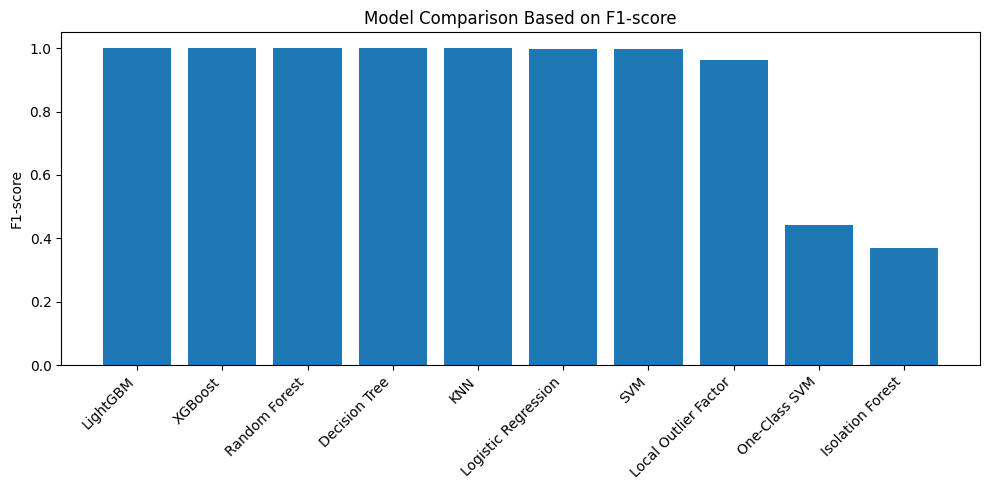

In [16]:
# =========================
# Bar chart: model comparison
# =========================

plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["F1-score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1-score")
plt.title("Model Comparison Based on F1-score")
plt.tight_layout()
plt.show()

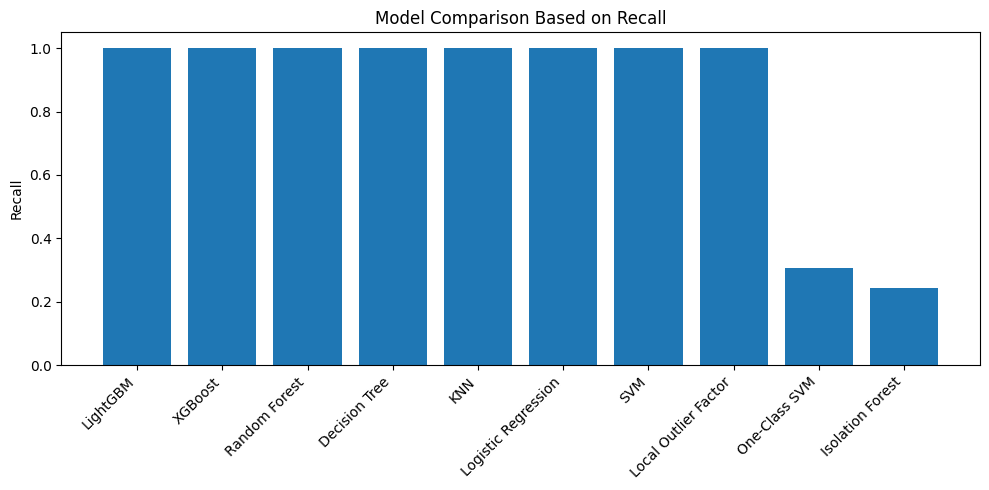

In [17]:
# =========================
# Plot Recall comparison
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(final_results["Model"], final_results["Recall"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Recall")

plt.title("Model Comparison Based on Recall")

plt.ylim(0, 1.05)

plt.tight_layout()

plt.show()

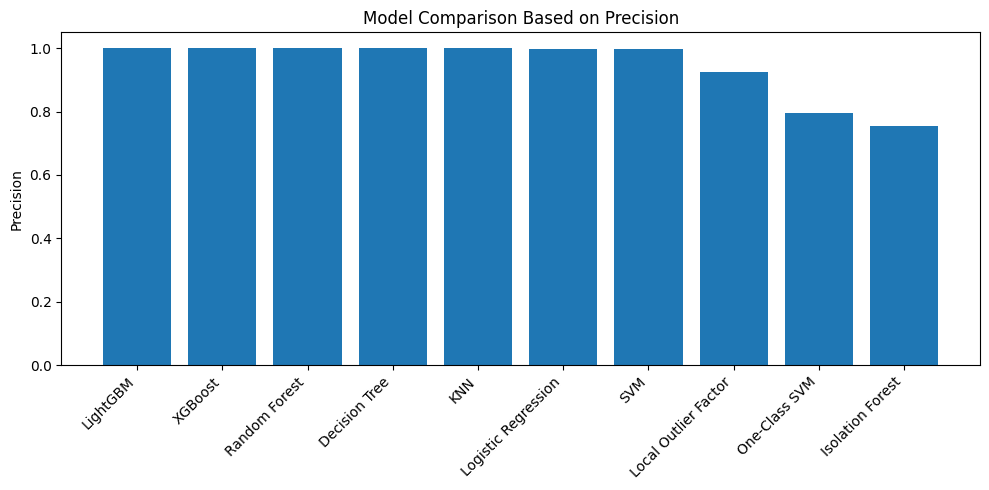

In [18]:
# =========================
# Plot Precision comparison
# =========================

plt.figure(figsize=(10,5))

plt.bar(final_results["Model"], final_results["Precision"])

plt.xticks(rotation=45, ha="right")

plt.ylabel("Precision")

plt.title("Model Comparison Based on Precision")

plt.ylim(0, 1.05)

plt.tight_layout()

plt.show()

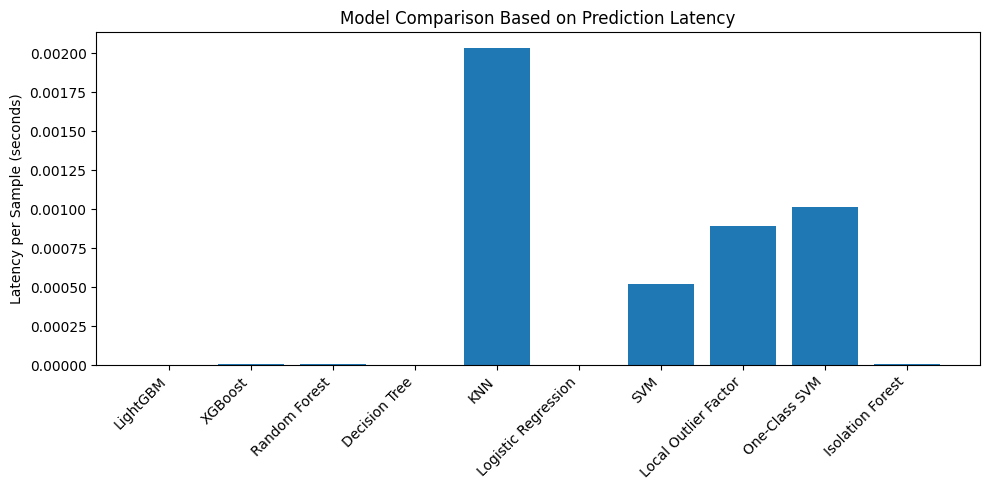

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(final_results["Model"], final_results["Latency per Sample (s)"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Latency per Sample (seconds)")
plt.title("Model Comparison Based on Prediction Latency")
plt.tight_layout()
plt.show()

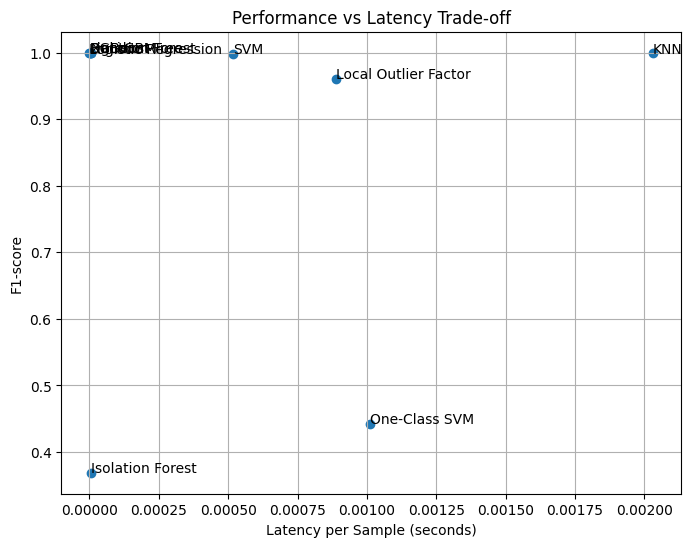

In [20]:
# =========================
# F1-score vs Latency
# =========================

plt.figure(figsize=(8,6))

plt.scatter(
    final_results["Latency per Sample (s)"],
    final_results["F1-score"]
)

for i, row in final_results.iterrows():
    plt.text(
        row["Latency per Sample (s)"],
        row["F1-score"],
        row["Model"]
    )

plt.xlabel("Latency per Sample (seconds)")
plt.ylabel("F1-score")

plt.title("Performance vs Latency Trade-off")

plt.grid(True)

plt.show()

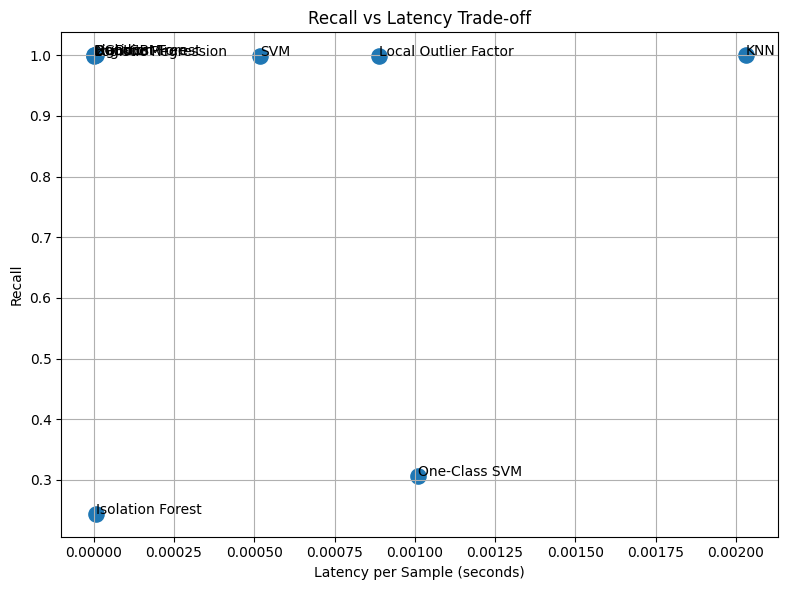

In [21]:
# =========================
# Recall vs Latency Trade-off
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    final_results["Latency per Sample (s)"],
    final_results["Recall"],
    s=120
)

# Add model labels
for i, row in final_results.iterrows():
    plt.text(
        row["Latency per Sample (s)"],
        row["Recall"],
        row["Model"],
        fontsize=10
    )

plt.xlabel("Latency per Sample (seconds)")
plt.ylabel("Recall")

plt.title("Recall vs Latency Trade-off")

plt.grid(True)

plt.tight_layout()

plt.show()

In [22]:
# =========================
# Feature importance function
# =========================

def get_feature_importance(model, model_name, features):
    importance = model.feature_importances_

    fi_df = pd.DataFrame({
        "Feature": features,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    print(f"\n{model_name} Feature Importance")
    display(fi_df)

    plt.figure(figsize=(8, 5))
    plt.barh(fi_df["Feature"], fi_df["Importance"])
    plt.gca().invert_yaxis()
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"{model_name} Feature Importance")
    plt.tight_layout()
    plt.show()

    return fi_df


Random Forest Feature Importance


,Feature,Importance
6,Fwd Packet Length Max,0.105632
53,Avg Fwd Segment Size,0.084187
66,Init_Win_bytes_forward,0.072932
4,Total Length of Fwd Packets,0.060450
8,Fwd Packet Length Mean,0.056714
...,...,...
58,Fwd Avg Bulk Rate,0.000000
57,Fwd Avg Packets/Bulk,0.000000
56,Fwd Avg Bytes/Bulk,0.000000
49,CWE Flag Count,0.000000


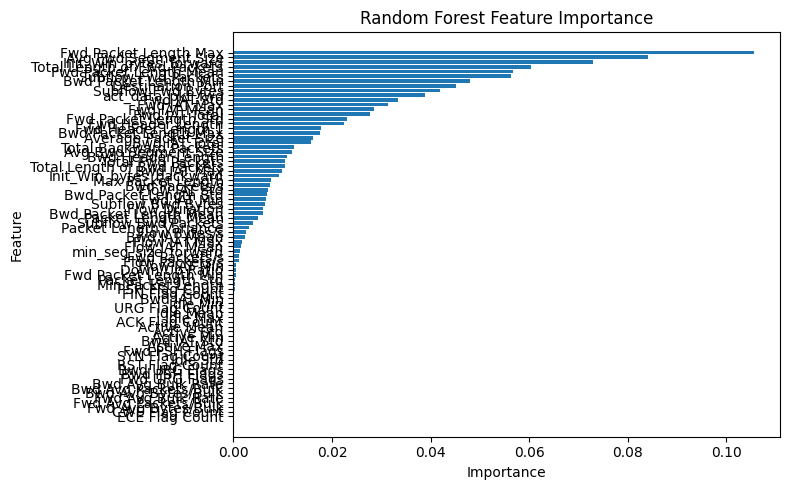


XGBoost Feature Importance


,Feature,Importance
8,Fwd Packet Length Mean,0.610255
4,Total Length of Fwd Packets,0.357900
2,Total Fwd Packets,0.004021
35,Bwd Header Length,0.003355
12,Bwd Packet Length Mean,0.003061
...,...,...
65,Subflow Bwd Bytes,0.000000
62,Subflow Fwd Packets,0.000000
63,Subflow Fwd Bytes,0.000000
71,Active Std,0.000000


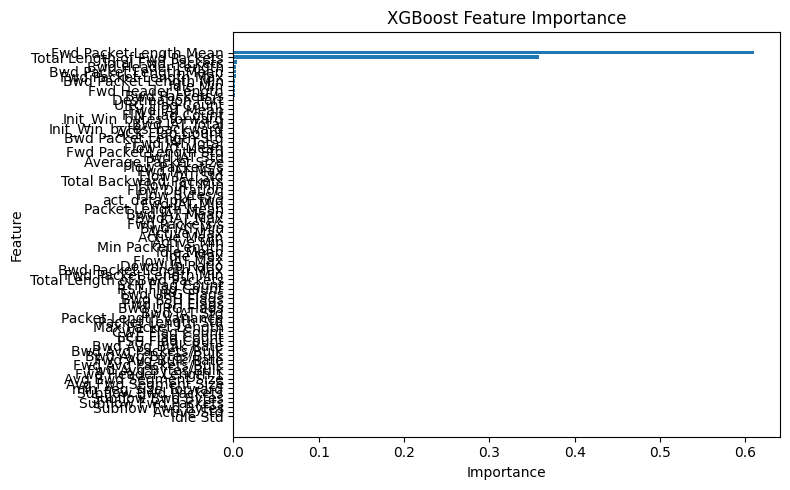


LightGBM Feature Importance


,Feature,Importance
0,Destination Port,568
66,Init_Win_bytes_forward,213
4,Total Length of Fwd Packets,174
19,Flow IAT Min,166
1,Flow Duration,149
...,...,...
65,Subflow Bwd Bytes,0
71,Active Std,0
74,Idle Mean,0
75,Idle Std,0


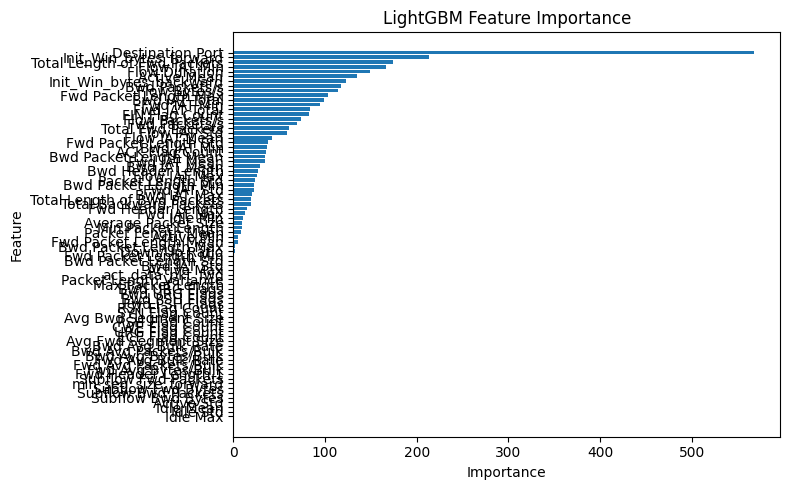

In [23]:
# =========================
# Feature importance from tree-based models
# =========================

rf_importance = get_feature_importance(
    trained_supervised_models["Random Forest"],
    "Random Forest",
    features
)

xgb_importance = get_feature_importance(
    trained_supervised_models["XGBoost"],
    "XGBoost",
    features
)

lgbm_importance = get_feature_importance(
    trained_supervised_models["LightGBM"],
    "LightGBM",
    features
)

In [24]:
# =========================
# Combined average feature importance
# =========================

combined_importance = pd.DataFrame({
    "Feature": features
})

combined_importance = combined_importance.merge(
    rf_importance.rename(columns={"Importance": "Random Forest"}),
    on="Feature"
)

combined_importance = combined_importance.merge(
    xgb_importance.rename(columns={"Importance": "XGBoost"}),
    on="Feature"
)

combined_importance = combined_importance.merge(
    lgbm_importance.rename(columns={"Importance": "LightGBM"}),
    on="Feature"
)

combined_importance["Average Importance"] = combined_importance[
    ["Random Forest", "XGBoost", "LightGBM"]
].mean(axis=1)

combined_importance = combined_importance.sort_values(
    by="Average Importance",
    ascending=False
)

combined_importance

,Feature,Random Forest,XGBoost,LightGBM,Average Importance
0,Destination Port,0.045161,0.001163,568,189.348775
66,Init_Win_bytes_forward,0.072932,0.000919,213,71.024617
4,Total Length of Fwd Packets,0.060450,0.357900,174,58.139450
19,Flow IAT Min,0.000614,0.000215,166,55.333610
1,Flow Duration,0.006051,0.000187,149,49.668746
...,...,...,...,...,...
58,Fwd Avg Bulk Rate,0.000000,0.000000,0,0.000000
57,Fwd Avg Packets/Bulk,0.000000,0.000000,0,0.000000
56,Fwd Avg Bytes/Bulk,0.000000,0.000000,0,0.000000
49,CWE Flag Count,0.000000,0.000000,0,0.000000


In [25]:
# =========================
# Save feature importance
# =========================

combined_importance.to_csv("feature_importance_results.csv", index=False)
print("Saved: feature_importance_results.csv")

Saved: feature_importance_results.csv


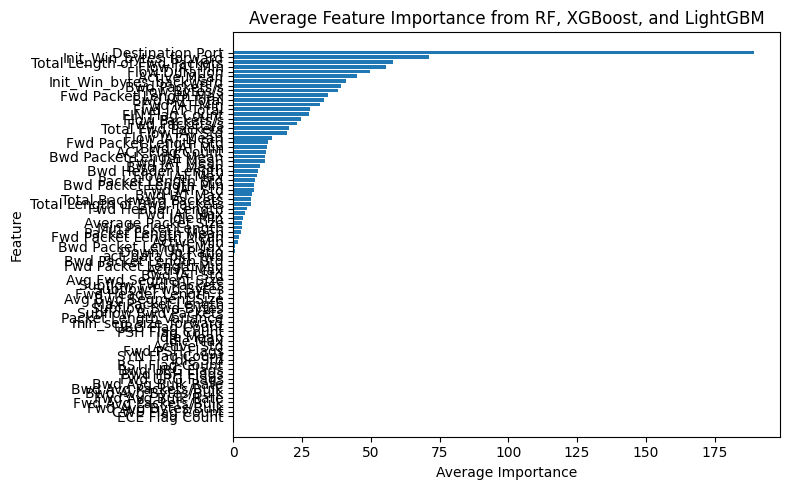

In [26]:
# =========================
# Plot average feature importance
# =========================

plt.figure(figsize=(8, 5))
plt.barh(
    combined_importance["Feature"],
    combined_importance["Average Importance"]
)
plt.gca().invert_yaxis()
plt.xlabel("Average Importance")
plt.ylabel("Feature")
plt.title("Average Feature Importance from RF, XGBoost, and LightGBM")
plt.tight_layout()
plt.show()

In [27]:
# =========================
# Print final best model and best features
# =========================

best_model = final_results.iloc[0]

print("Best Model:")
print(best_model)

print("\nTop 10 Important Features:")
display(combined_importance.head(10))

Best Model:
Model                       LightGBM
Type                      Supervised
Accuracy                    0.999978
Precision                        1.0
Recall                      0.999961
F1-score                     0.99998
AUC                              1.0
Training Time (s)           6.770995
Prediction Time (s)         0.115195
Latency per Sample (s)      0.000003
Name: 6, dtype: object

Top 10 Important Features:


,Feature,Random Forest,XGBoost,LightGBM,Average Importance
0,Destination Port,0.045161,0.001163,568,189.348775
66,Init_Win_bytes_forward,0.072932,0.000919,213,71.024617
4,Total Length of Fwd Packets,0.060450,0.357900,174,58.139450
19,Flow IAT Min,0.000614,0.000215,166,55.333610
1,Flow Duration,0.006051,0.000187,149,49.668746
70,Active Mean,0.000025,0.000041,135,45.000022
67,Init_Win_bytes_backward,0.009284,0.000544,123,41.003276
37,Bwd Packets/s,0.007356,0.001458,117,39.002938
14,Flow Bytes/s,0.002579,0.000183,114,38.000921
6,Fwd Packet Length Max,0.105632,0.002518,103,34.369383
